Lutas REALIZADO: 2524 | Período: 2017-2026
Decisivas: 2510 | Title fights: 146

[Q1] Spearman (year vs duration, non-title): rho=-0.010, p=0.6352, n=2347

[Q2] Qui-quadrado pre/post-2020: chi2=8.16, p=0.04287, V de Cramer=0.057, n=2510

[Q3] Classes analisadas: 10
                      n    mean   std  median
weight_class_clean                           
Heavyweight         249  189.01  5.96  187.96
Light Heavyweight   190  187.25  5.09  187.96
Middleweight        380  185.75  5.08  185.42
Welterweight        587  181.30  5.47  180.34
Lightweight         615  178.26  5.07  177.80
Catchweight         488  175.56  7.28  175.26
Featherweight       638  175.40  5.06  175.26
Bantamweight        610  170.76  4.75  170.18
Flyweight           575  167.31  5.06  167.64
Strawweight         261  160.71  4.76  160.02

[Q4] Resultados por classe:
            group   n  win_rate  ci_low  ci_high  p_value  p_adjusted  significant
Light Heavyweight  80    0.5875  0.4780   0.6889   0.1456      0.6295  

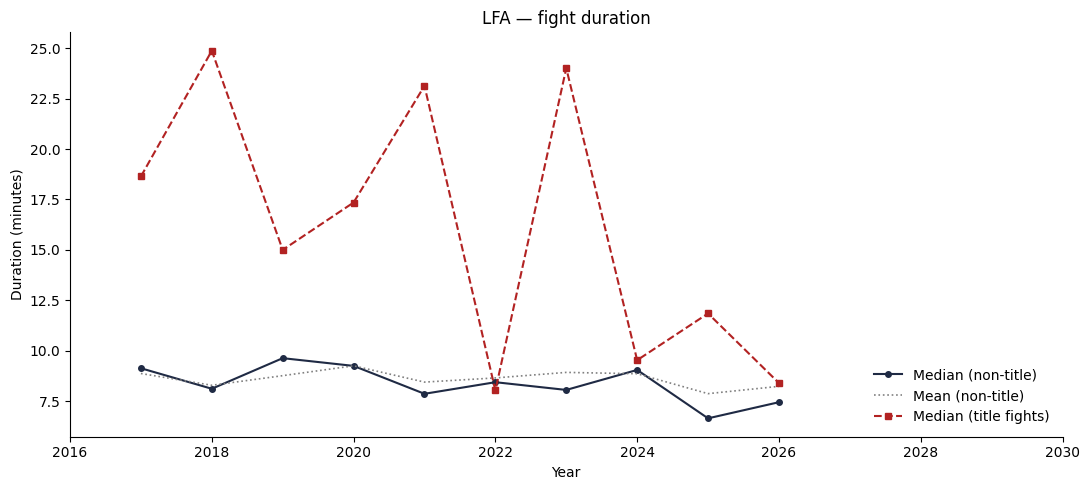

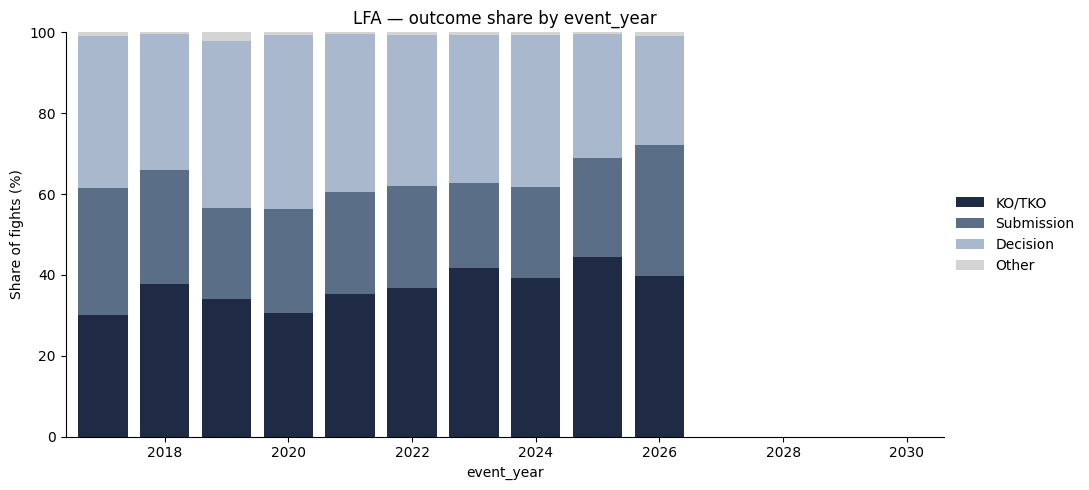

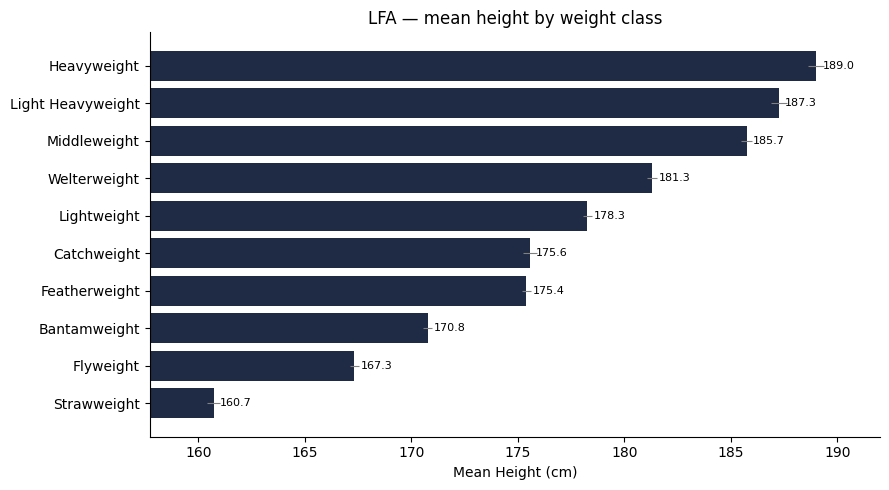

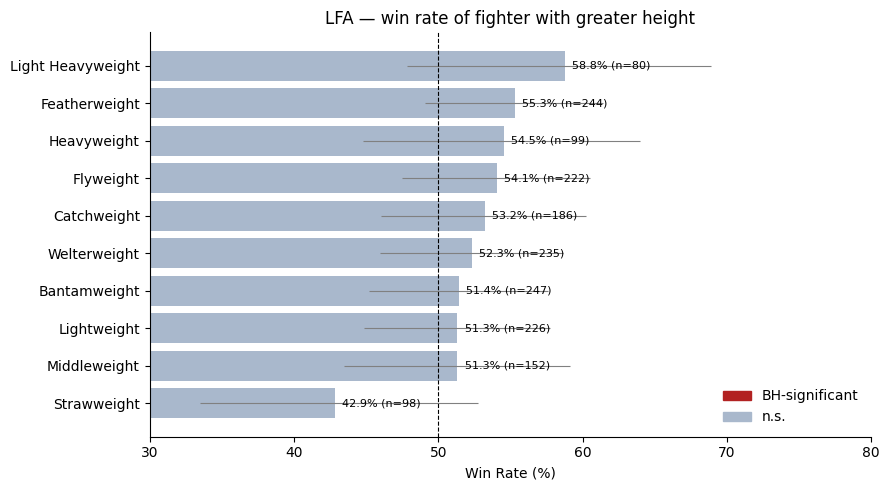

In [1]:
import re
import json
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from matplotlib.ticker import MaxNLocator
from scipy import stats
from statsmodels.stats.multitest import multipletests
import statsmodels.api as sm


DATA_DIR = '/kaggle/input/datasets/leandroiber/lfa-mma-dataset'
CSV_PATH = f'{DATA_DIR}/clean_sherdog_lfa.csv'
JSON_PATH = f'{DATA_DIR}/lfa_win_title_data.json'


def temporal_aggregation(df, time_col, value_col, group_col=None,
                         agg_funcs=('median', 'mean'), trend_test=True):
    funcs = list(agg_funcs) + ['count', 'std']
    if group_col is None:
        agg = df.groupby(time_col)[value_col].agg(funcs)
    else:
        agg = df.groupby([time_col, group_col])[value_col].agg(funcs).unstack()

    out = {'aggregation': agg}
    if trend_test:
        clean = df[[time_col, value_col]].dropna()
        if len(clean) > 3:
            rho, p = stats.spearmanr(clean[time_col], clean[value_col])
            out['spearman'] = {'rho': rho, 'p_value': p, 'n': len(clean)}
    return out


def categorical_composition_over_time(df, time_col, category_col,
                                      split_point=None, normalize=True):
    counts = df.groupby([time_col, category_col]).size().unstack(fill_value=0)
    proportions = counts.div(counts.sum(axis=1), axis=0) if normalize else counts

    out = {'proportions': proportions, 'counts': counts}

    if split_point is not None:
        before = df[df[time_col] < split_point][category_col].value_counts()
        after = df[df[time_col] >= split_point][category_col].value_counts()
        contingency = pd.DataFrame({'before': before, 'after': after}).fillna(0)
        chi2, p, dof, _ = stats.chi2_contingency(contingency)
        n = contingency.sum().sum()
        cramers_v = np.sqrt(chi2 / (n * (min(contingency.shape) - 1)))
        out['regime_test'] = {
            'chi2': chi2, 'p_value': p, 'dof': dof,
            'cramers_v': cramers_v, 'n': int(n),
            'contingency': contingency
        }
    return out


def group_descriptive(df, group_col, value_col, min_n=5):
    g = df.dropna(subset=[group_col, value_col]).groupby(group_col)[value_col]
    out = g.agg(['count', 'mean', 'std', 'median',
                 lambda x: x.quantile(0.25),
                 lambda x: x.quantile(0.75)])
    out.columns = ['n', 'mean', 'std', 'median', 'q25', 'q75']
    out['iqr'] = out['q75'] - out['q25']
    out = out[out['n'] >= min_n]
    return out.sort_values('mean', ascending=False)


def paired_advantage_test(df, group_col, attr_a_col, attr_b_col,
                          winner_is_a_col=None,
                          min_n=30, mc_method='fdr_bh', alpha=0.05):
    results = []
    for group, sub in df.groupby(group_col):
        sub = sub.dropna(subset=[attr_a_col, attr_b_col]).copy()
        if winner_is_a_col is not None:
            sub = sub.dropna(subset=[winner_is_a_col])
            a_won = sub[winner_is_a_col].astype(bool)
        else:
            a_won = pd.Series(True, index=sub.index)

        sub = sub[sub[attr_a_col] != sub[attr_b_col]]
        a_won = a_won.loc[sub.index]
        n = len(sub)

        if n < min_n:
            results.append({'group': group, 'n': n, 'underpowered': True})
            continue

        a_greater = sub[attr_a_col] > sub[attr_b_col]
        greater_won = (a_greater & a_won) | (~a_greater & ~a_won)
        wins = int(greater_won.sum())

        ci_low, ci_high = stats.binomtest(wins, n).proportion_ci(method='wilson')
        p_value = stats.binomtest(wins, n, p=0.5, alternative='two-sided').pvalue

        results.append({
            'group': group, 'n': n, 'win_rate': wins / n,
            'ci_low': ci_low, 'ci_high': ci_high,
            'p_value': p_value, 'underpowered': False
        })

    res = pd.DataFrame(results)
    res['p_adjusted'] = np.nan
    res['significant'] = False
    res['underpowered'] = res['underpowered'].astype(bool)

    valid = ~res['underpowered']
    if valid.sum() > 0:
        _, p_adj, _, _ = multipletests(res.loc[valid, 'p_value'],
                                       method=mc_method, alpha=alpha)
        res.loc[valid, 'p_adjusted'] = p_adj
        res.loc[valid, 'significant'] = p_adj < alpha
    return res.sort_values('win_rate', ascending=False, na_position='last')


def continuous_advantage_logit(df, group_col, diff_cols, target_col,
                               covariates=None, min_n=50):
    rows = []
    cols = list(diff_cols) + (covariates or [])
    for group, sub in df.groupby(group_col):
        sub = sub.dropna(subset=cols + [target_col])
        if len(sub) < min_n:
            continue
        X = sm.add_constant(sub[cols])
        y = sub[target_col].astype(int)
        try:
            m = sm.Logit(y, X).fit(disp=0)
            for c in cols:
                rows.append({
                    'group': group, 'predictor': c, 'n': len(sub),
                    'coef': m.params[c],
                    'odds_ratio': np.exp(m.params[c]),
                    'p_value': m.pvalues[c],
                    'or_ci_low': np.exp(m.conf_int().loc[c, 0]),
                    'or_ci_high': np.exp(m.conf_int().loc[c, 1]),
                    'pseudo_r2': m.prsquared
                })
        except Exception as e:
            rows.append({'group': group, 'error': str(e)})
    return pd.DataFrame(rows)


def load_lfa():
    df = pd.read_csv(CSV_PATH)
    df = df[df['event_status'] == 'REALIZADO'].copy()
    df['event_date'] = pd.to_datetime(df['event_date'], utc=True, errors='coerce')
    df['event_year'] = df['event_date'].dt.year

    def time_to_min(row):
        try:
            m, s = map(int, str(row['time']).split(':'))
            return (int(row['round_num']) - 1) * 5 + m + s / 60
        except (ValueError, TypeError):
            return np.nan
    df['duration_min'] = df.apply(time_to_min, axis=1)

    def bucket_method(m):
        if pd.isna(m):
            return np.nan
        m = m.lower()
        if 'submission' in m:
            return 'Submission'
        if 'ko' in m or 'tko' in m:
            return 'KO/TKO'
        if 'decision' in m:
            return 'Decision'
        return 'Other'
    df['method_bucket'] = df['method'].apply(bucket_method)

    df['weight_class_clean'] = df['weight_class'].apply(
        lambda x: 'Catchweight' if pd.notna(x) and re.search(r'Catch', str(x), re.I) else x
    )

    df['decisive'] = df['fighter_1_result'] == 'win'

    with open(JSON_PATH) as f:
        title_data = json.load(f)
    title_map = {}
    for k, v in title_data.items():
        key = (v.get('event_date'), v.get('fighter_1'), v.get('fighter_2'))
        title_map[key] = v.get('is_title_fight', False)
    df['_date_str'] = df['event_date'].dt.strftime('%Y-%m-%d')
    df['is_title_fight'] = df.apply(
        lambda r: title_map.get((r['_date_str'], r['fighter_1'], r['fighter_2']), False),
        axis=1
    )
    df = df.drop(columns=['_date_str'])
    return df


def q1_duration_over_time(df, x_max=2030):
    non_title = df[~df['is_title_fight'] & df['decisive']]
    title = df[df['is_title_fight'] & df['decisive']]

    nt_res = temporal_aggregation(non_title, 'event_year', 'duration_min')
    t_res = temporal_aggregation(title, 'event_year', 'duration_min', trend_test=False)

    fig, ax = plt.subplots(figsize=(11, 5))
    nt_agg = nt_res['aggregation']
    ax.plot(nt_agg.index, nt_agg['median'], '-o', color='#1f2a44',
            label='Median (non-title)', markersize=4)
    ax.plot(nt_agg.index, nt_agg['mean'], ':', color='gray',
            label='Mean (non-title)', linewidth=1.2)
    if len(t_res['aggregation']) > 0:
        t_agg = t_res['aggregation']
        ax.plot(t_agg.index, t_agg['median'], '--s', color='#b22222',
                label='Median (title fights)', markersize=4)
    ax.set_xlabel('Year')
    ax.set_ylabel('Duration (minutes)')
    ax.set_title('LFA — fight duration')
    ax.legend(loc='lower right', frameon=False)
    ax.set_xlim(df['event_year'].min() - 1, x_max)
    ax.xaxis.set_major_locator(MaxNLocator(integer=True, nbins=10))
    sns.despine()
    plt.tight_layout()
    return fig, nt_res, t_res


def q2_outcome_share_over_time(df, split_year=2020, x_max=2030):
    decisive = df[df['decisive']].dropna(subset=['method_bucket'])
    res = categorical_composition_over_time(
        decisive, 'event_year', 'method_bucket', split_point=split_year
    )

    order = ['KO/TKO', 'Submission', 'Decision', 'Other']
    props = res['proportions'].reindex(columns=order, fill_value=0) * 100

    fig, ax = plt.subplots(figsize=(11, 5))
    palette = {'KO/TKO': '#1f2a44', 'Submission': '#5b6e88',
               'Decision': '#a9b8cc', 'Other': '#d4d4d4'}
    bottom = np.zeros(len(props))
    for cat in order:
        ax.bar(props.index, props[cat], bottom=bottom, label=cat, color=palette[cat])
        bottom += props[cat].values
    ax.set_xlabel('event_year')
    ax.set_ylabel('Share of fights (%)')
    ax.set_title('LFA — outcome share by event_year')
    ax.legend(loc='center left', bbox_to_anchor=(1, 0.5), frameon=False)
    ax.set_ylim(0, 100)
    ax.set_xlim(props.index.min() - 0.6, x_max + 0.6)
    ax.xaxis.set_major_locator(MaxNLocator(integer=True, nbins=10))
    sns.despine()
    plt.tight_layout()
    return fig, res


def q3_height_by_weight_class(df, min_n=10):
    valid_classes = df['weight_class_clean'].value_counts()
    valid_classes = valid_classes[valid_classes >= min_n].index
    sub = df[df['weight_class_clean'].isin(valid_classes)]

    long = pd.concat([
        sub[['weight_class_clean', 'f1_height_cm']].rename(columns={'f1_height_cm': 'height'}),
        sub[['weight_class_clean', 'f2_height_cm']].rename(columns={'f2_height_cm': 'height'})
    ])
    desc = group_descriptive(long, 'weight_class_clean', 'height', min_n=min_n)

    fig, ax = plt.subplots(figsize=(9, 5))
    desc_sorted = desc.sort_values('mean')
    ax.barh(desc_sorted.index, desc_sorted['mean'], color='#1f2a44',
            xerr=desc_sorted['std'] / np.sqrt(desc_sorted['n']),
            error_kw={'ecolor': 'gray', 'linewidth': 0.8})
    for i, (idx, row) in enumerate(desc_sorted.iterrows()):
        ax.text(row['mean'] + 0.3, i, f"{row['mean']:.1f}",
                va='center', fontsize=8)
    ax.set_xlabel('Mean Height (cm)')
    ax.set_title('LFA — mean height by weight class')
    ax.set_xlim(desc_sorted['mean'].min() - 3, desc_sorted['mean'].max() + 3)
    sns.despine()
    plt.tight_layout()
    return fig, desc


def q4_height_advantage(df, min_n=30):
    sub = df[df['decisive']].dropna(
        subset=['f1_height_cm', 'f2_height_cm', 'weight_class_clean']
    ).copy()
    valid_classes = sub['weight_class_clean'].value_counts()
    sub = sub[sub['weight_class_clean'].isin(valid_classes[valid_classes >= min_n].index)]

    sub['winner_is_f1'] = True
    res = paired_advantage_test(
        sub, group_col='weight_class_clean',
        attr_a_col='f1_height_cm', attr_b_col='f2_height_cm',
        winner_is_a_col='winner_is_f1', min_n=min_n
    )

    fig, ax = plt.subplots(figsize=(9, 5))
    valid = res[~res['underpowered']].copy()
    valid = valid.sort_values('win_rate')
    colors = ['#b22222' if s else '#a9b8cc' for s in valid['significant']]
    ax.barh(valid['group'], valid['win_rate'] * 100, color=colors,
            xerr=[(valid['win_rate'] - valid['ci_low']) * 100,
                  (valid['ci_high'] - valid['win_rate']) * 100],
            error_kw={'ecolor': 'gray', 'linewidth': 0.8})
    ax.axvline(50, ls='--', color='black', linewidth=0.8)
    for i, (_, row) in enumerate(valid.iterrows()):
        ax.text(row['win_rate'] * 100 + 0.5, i,
                f"{row['win_rate']*100:.1f}% (n={row['n']})",
                va='center', fontsize=8)
    ax.set_xlabel('Win Rate (%)')
    ax.set_title('LFA — win rate of fighter with greater height')
    ax.set_xlim(30, 80)
    handles = [plt.Rectangle((0, 0), 1, 1, color='#b22222'),
               plt.Rectangle((0, 0), 1, 1, color='#a9b8cc')]
    ax.legend(handles, ['BH-significant', 'n.s.'], loc='lower right', frameon=False)
    sns.despine()
    plt.tight_layout()
    return fig, res


if __name__ == '__main__':
    df = load_lfa()
    print(f"Lutas REALIZADO: {len(df)} | Período: {df['event_year'].min()}-{df['event_year'].max()}")
    print(f"Decisivas: {df['decisive'].sum()} | Title fights: {df['is_title_fight'].sum()}")

    fig1, q1_nt, q1_t = q1_duration_over_time(df)
    fig1.savefig('q1_lfa_duration.png', dpi=120, bbox_inches='tight')
    print(f"\n[Q1] Spearman (year vs duration, non-title): "
          f"rho={q1_nt['spearman']['rho']:.3f}, "
          f"p={q1_nt['spearman']['p_value']:.4g}, "
          f"n={q1_nt['spearman']['n']}")

    fig2, q2 = q2_outcome_share_over_time(df, split_year=2020)
    fig2.savefig('q2_lfa_outcomes.png', dpi=120, bbox_inches='tight')
    rt = q2['regime_test']
    print(f"\n[Q2] Qui-quadrado pre/post-2020: "
          f"chi2={rt['chi2']:.2f}, p={rt['p_value']:.4g}, "
          f"V de Cramer={rt['cramers_v']:.3f}, n={rt['n']}")

    fig3, q3 = q3_height_by_weight_class(df, min_n=10)
    fig3.savefig('q3_lfa_height.png', dpi=120, bbox_inches='tight')
    print(f"\n[Q3] Classes analisadas: {len(q3)}")
    print(q3[['n', 'mean', 'std', 'median']].round(2))

    fig4, q4 = q4_height_advantage(df, min_n=30)
    fig4.savefig('q4_lfa_height_winrate.png', dpi=120, bbox_inches='tight')
    print(f"\n[Q4] Resultados por classe:")
    cols_show = ['group', 'n', 'win_rate', 'ci_low', 'ci_high', 'p_value', 'p_adjusted', 'significant']
    print(q4[cols_show].round(4).to_string(index=False))

## Q1 > Fight Duration Over Time
The non-title series is essentially stationary across the 2017-2026 window. The median oscillates in a narrow band between roughly 7 and 9.7 minutes throughout the period, without a discernible upward or downward shift. The mean tracks the median tightly, often within 0.5 minutes, indicating a clean and consistent distribution across years. The central tendency of fight length has not moved in either direction over the ten-year window, which is a distinctive feature of this series.

The stability of the non-title series indicates that the matchmaking profile and roster composition have remained consistent in their finish-density characteristics. The promotion operates as a developmental tier where fights regularly produce mid-round finishes, which keeps the median anchored in the 7-10 minute range rather than pushing it toward the 15-minute regulation ceiling.

Title fights (red dashed line, n = 145 across 10 years) display the typical sparsity-driven volatility, with annual medians ranging from 8 minutes (2022) to 25 minutes (2018). With an average of roughly 15 title bouts per year, the title series is denser than at promotions with sparser championship calendars, but individual years still oscillate by 10-15 minutes. The pattern shows no consistent direction over the period.
The 2026 datapoint should be read with caution since the year may be incomplete relative to the full calendar. The 7-7.5 minute level for the non-title median is consistent with the broader stationary pattern and is not necessarily a sign of a recent change.

## Q2 > Outcome Distribution Over Time
The outcome composition shows a marginal statistical result. The test returns χ² = 8.71, p = 0.033, with Cramér's V = 0.059. The p-value is below the α = 0.05 threshold, but the effect size is very small (V < 0.1 is conventionally considered negligible). This is a case where the statistical significance is driven by the large sample size (n = 2501) rather than by a meaningful change in composition. The null hypothesis is technically rejected, but the practical interpretation is that the composition has remained substantively stable over the period.

Year-by-year visual composition confirms the stability. KO/TKO accounts for roughly 30-44% of decisive fights across all years, submissions for 17-30%, and decisions for 27-43%. The post-2024 years show a slight tilt toward KO/TKO (40-45% range) and away from decisions, but the shift is modest and could regress with additional data.

The composition reflects a balanced developmental product: finishes account for roughly 60-70% of decisive outcomes across the full window, with submissions and KO/TKO splitting that share. This is consistent with a roster of younger, less established fighters whose style asymmetries are larger and whose technical mismatches produce more finishes than at promotions with elite-parity matchmaking.
The 2026 bar is built on incomplete data and should not be read as a regime signal on its own.

## Q3 > Mean Height by Weight Class
The ordinal progression is clean and well-behaved across all ten classes. Heavyweight (189.0 cm, n = 249) leads, followed by Light Heavyweight (187.3 cm, n = 190), with a 1.7 cm gap between the two top divisions. This indicates that the Heavyweight class has access to a real 190+ cm fighter pool rather than topping out at the Light Heavyweight ceiling. The within-class standard deviations are tight (4.5 to 5.5 cm in most divisions), indicating consistent roster construction.

The absolute height levels sit close to international medians, consistent with a roster drawn from a globally diverse but US-anchored fighter pool. The promotion operates as a developmental tier in the North American MMA ecosystem and sources talent primarily from the United States, Brazil, and the broader international circuit. American adult male mean stature is approximately 175-177 cm, which aligns with the Lightweight (178.3) and Featherweight (175.4) means, while the heavier divisions (Welterweight 181.3, Middleweight 185.7) reflect the upper portion of the height distribution drawn from the same pool. The roster does not show a pronounced regional skew in either direction.

The Catchweight bucket (175.4 cm, n = 478) is one of the larger categories in the dataset and has by far the highest within-class standard deviation (7.27 cm vs 4.5 to 5.5 cm in the standard divisions). Catchweight is used extensively as a matchmaking instrument, and the bucket aggregates fighters across a wide weight range. The mean coincides exactly with the Featherweight mean (175.4 cm), which is coincidental and does not imply that the two categories draw from the same weight distribution. The Featherweight mean reflects fighters with a 145 lb weight ceiling, while the Catchweight mean reflects a weighted central tendency across a much wider weight range.

The sample sizes across all major divisions are substantial (Featherweight n = 635, Lightweight n = 611, Bantamweight n = 610), and even the smaller divisions (Strawweight n = 260, Flyweight n = 575) have enough observations for reliable estimates.

## Q4 > Win Rate by Height Advantage
No class reaches statistical significanceafter correcting for multiple testing, and no class reaches raw significance either. The strongest directional signal is Light Heavyweight at 58.8% (n = 80, raw p = 0.146), which is suggestive but well outside the threshold. The formal conclusion is straightforward: the evidence is insufficient to reject the null hypothesis of no height effect in any division.

The directional pattern is unusually flat. Most classes cluster very tightly around the 50% baseline: Featherweight (54.9%), Heavyweight (54.5%), Flyweight (54.1%), Catchweight (53.6%), Welterweight (52.3%), Lightweight (51.6%), Bantamweight (51.4%), and Middleweight (51.3%). Eight of the ten tested classes sit within 5 percentage points of the baseline. The compression of the point estimates around 50% is the defining characteristic of this dataset and limits the ability to detect a meaningful height effect even with large samples.

Strawweight is the only class with a marked reversal at 43.3% (n = 97), where the shorter fighter wins meaningfully more often than the baseline would predict. The raw p-value (0.223) does not reach significance, but the directional magnitude is large enough to warrant separate investigation. This aligns with the broader pattern of the lightest divisions being either neutral or reversed relative to height, since reach and distance management likely confer less advantage where fighters operate closer to the ground and grappling exchanges happen at shorter ranges.

The overall picture is of a roster where height does not strongly differentiate winners from losers at any weight. Two non-exclusive interpretations are consistent with the data: the developmental tier produces matchups where technical mismatches and experience gaps dominate over physical asymmetries, and the height variance within each class may be too tight at this level of competition for the effect to manifest at detectable magnitudes.

All ten classes met the n ≥ 30 threshold and were included in the test.